# EDA 04 — Darwin Timetable

**Data source**: `darwin-timetable-feeds` Azure container — XML timetable files  
**Loaded by**: `src/data_loader.load_darwin_timetable()`  
**Output**: `data/processed/darwin_timetable_clean.parquet`

The Darwin timetable provides the scheduled service plan for the observation period. Unlike train moments (which record what actually happened), the timetable records what was planned. It is used in the main notebook to generate forward-looking delay predictions for scheduled services. This EDA examines the structure, coverage, and quality of the timetable data independently before it enters the join pipeline.

---
**Sections**
1. Load and inspect  
2. Missing value audit  
3. TOC (train operating company) distribution  
4. Stop type distribution  
5. Service date coverage  
6. Planned time field coverage (wta / wtd / wtp)  
7. Service frequency by hour  
8. Journey-level statistics (stops per journey)  
9. TIPLOC match rate  
10. Save cleaned output  


## 0. Setup

In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.insert(0, "..")
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", 40)
os.makedirs("figures/eda_04", exist_ok=True)
os.makedirs("./data/processed", exist_ok=True)
%matplotlib inline

## 1. Load and Inspect

In [3]:
from datetime import datetime, timezone
from src.data_loader import load_darwin_timetable

# Load stations_reference.parquet for station code mapping
stations_reference_df = pd.read_parquet(
    "./data/processed/stations_reference.parquet",
    engine="pyarrow"
)

START = datetime(2026, 4, 10, 0, 0, 0, tzinfo=timezone.utc)
END   = datetime(2026, 4, 12, 23, 59, 59, tzinfo=timezone.utc)

timetable_df = load_darwin_timetable(START, END)
print(f"Shape: {timetable_df.shape}")
print(f"Columns: {list(timetable_df.columns)}")

Processing data\darwin_timetable\PPTimetable_20260410020459_v8.json with 65734 journeys
Processing data\darwin_timetable\PPTimetable_20260412020459_v8.json with 55999 journeys
Shape: (1898719, 14)
Columns: ['rid', 'uid', 'trainId', 'ssd', 'toc', 'stop_type', 'tpl', 'platform', 'act', 'pta', 'ptd', 'wta', 'wtd', 'wtp']


In [4]:
timetable_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898719 entries, 0 to 1898718
Data columns (total 14 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   rid        object
 1   uid        object
 2   trainId    object
 3   ssd        object
 4   toc        object
 5   stop_type  object
 6   tpl        object
 7   platform   object
 8   act        object
 9   pta        object
 10  ptd        object
 11  wta        object
 12  wtd        object
 13  wtp        object
dtypes: object(14)
memory usage: 202.8+ MB


In [5]:
timetable_df.head(10)

,rid,uid,trainId,ssd,toc,stop_type,tpl,platform,act,pta,ptd,wta,wtd,wtp
0,202604108062281,P62281,2S69,2026-04-10,SW,OR,WATRLMN,18,TB,None,21:22,None,21:22,None
1,202604108062281,P62281,2S69,2026-04-10,SW,PP,WATRLWC,None,None,None,None,None,None,21:23:30
2,202604108062281,P62281,2S69,2026-04-10,SW,IP,VAUXHLM,None,T,21:26,21:26,21:25:30,21:26:30,None
3,202604108062281,P62281,2S69,2026-04-10,SW,PP,NINELMJ,None,None,None,None,None,None,21:28
4,202604108062281,P62281,2S69,2026-04-10,SW,IP,QTRDBAT,3,T,21:29,21:29,21:29,21:29:30,None
5,202604108062281,P62281,2S69,2026-04-10,SW,IP,CLPHMJW,5,T,21:32,21:32,21:31:30,21:32:30,None
6,202604108062281,P62281,2S69,2026-04-10,SW,IP,WDWTOWN,2,T,21:35,21:35,21:34:30,21:35,None
7,202604108062281,P62281,2S69,2026-04-10,SW,IP,PUTNEY,None,T,21:37,21:38,21:37,21:38,None
8,202604108062281,P62281,2S69,2026-04-10,SW,IP,BARNES,3,T,21:41,21:42,21:40:30,21:42:30,None
9,202604108062281,P62281,2S69,2026-04-10,SW,IP,BNSBDGE,2,T,21:44,21:44,21:44,21:44:30,None


In [6]:
timetable_df.describe(include="all").T

,count,unique,top,freq
rid,1898719,121121,202604106775334,150
uid,1898719,85263,C75334,300
trainId,1898719,9349,0B00,48442
ssd,1898719,6,2026-04-10,542722
toc,1898719,39,NT,188500
stop_type,1898719,8,IP,865609
tpl,1898626,5003,WATRLMN,4940
platform,1028895,210,1,368643
act,1141492,190,T,844826
pta,959065,1439,18:09,1134


## 2. Missing Value Audit

In [8]:
missing = pd.DataFrame({
    "missing_count": timetable_df.isna().sum(),
    "missing_pct": (timetable_df.isna().sum() / len(timetable_df) * 100).round(2)
}).sort_values("missing_pct", ascending=False)
print(missing.to_string())

           missing_count  missing_pct
wtp              1138545        59.96
ptd               940799        49.55
pta               939654        49.49
wta               882017        46.45
wtd               882036        46.45
platform          869824        45.81
act               757227        39.88
toc                    0         0.00
stop_type              0         0.00
trainId                0         0.00
uid                    0         0.00
rid                    0         0.00
ssd                    0         0.00
tpl                   93         0.00


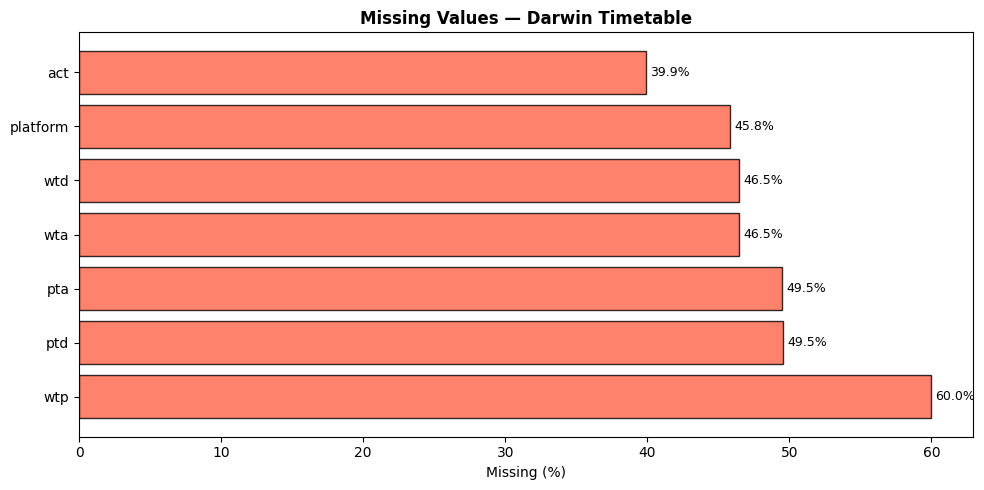

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
missing_nz = missing[missing["missing_pct"] > 0]
if len(missing_nz):
    ax.barh(missing_nz.index, missing_nz["missing_pct"], color="tomato", edgecolor="black", alpha=0.8)
    ax.set_xlabel("Missing (%)")
    ax.set_title("Missing Values — Darwin Timetable", fontweight="bold")
    for i, v in enumerate(missing_nz["missing_pct"]):
        ax.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=9)
else:
    ax.text(0.5, 0.5, "No missing values", ha="center", va="center",
            transform=ax.transAxes, fontsize=14)
plt.tight_layout()
plt.savefig("figures/eda_04/missing_values.png", dpi=200, bbox_inches="tight")
plt.show()

In [10]:
# Time field coverage — critical for schedule reshaping
for col in ["wta", "wtd", "wtp", "pta", "ptd"]:
    if col in timetable_df.columns:
        pct = timetable_df[col].notna().mean() * 100
        print(f"{col}: {timetable_df[col].notna().sum():,} non-null ({pct:.1f}%)")

wta: 1,016,702 non-null (53.5%)
wtd: 1,016,683 non-null (53.5%)
wtp: 760,174 non-null (40.0%)
pta: 959,065 non-null (50.5%)
ptd: 957,920 non-null (50.5%)


## 3. TOC (Train Operating Company) Distribution

In [11]:
if "toc" in timetable_df.columns:
    toc_counts = timetable_df["toc"].value_counts()
    print(f"Unique TOCs: {len(toc_counts)}")
    print()
    # Journey-level TOC (deduplicate by rid)
    journey_toc = timetable_df.drop_duplicates(subset=["rid"])["toc"].value_counts()
    print("Journeys per TOC:")
    print(journey_toc.to_string())

Unique TOCs: 39

Journeys per TOC:
toc
SR    13480
NT    12332
SW     9586
GW     9531
SE     8354
SN     7960
LO     6755
LE     6306
AW     5663
LM     5493
XR     4646
TL     4480
LT     3824
EM     2811
TP     2716
ME     2688
GN     2094
VT     2049
XC     1968
CC     1903
GR     1665
CH     1658
TW      660
HX      591
GX      336
SJ      303
ZZ      273
ES      246
IL      202
GC      127
HT      102
CS       93
LD       90
WR       49
LF       32
TY       23
LS       20
MV        6
SO        6


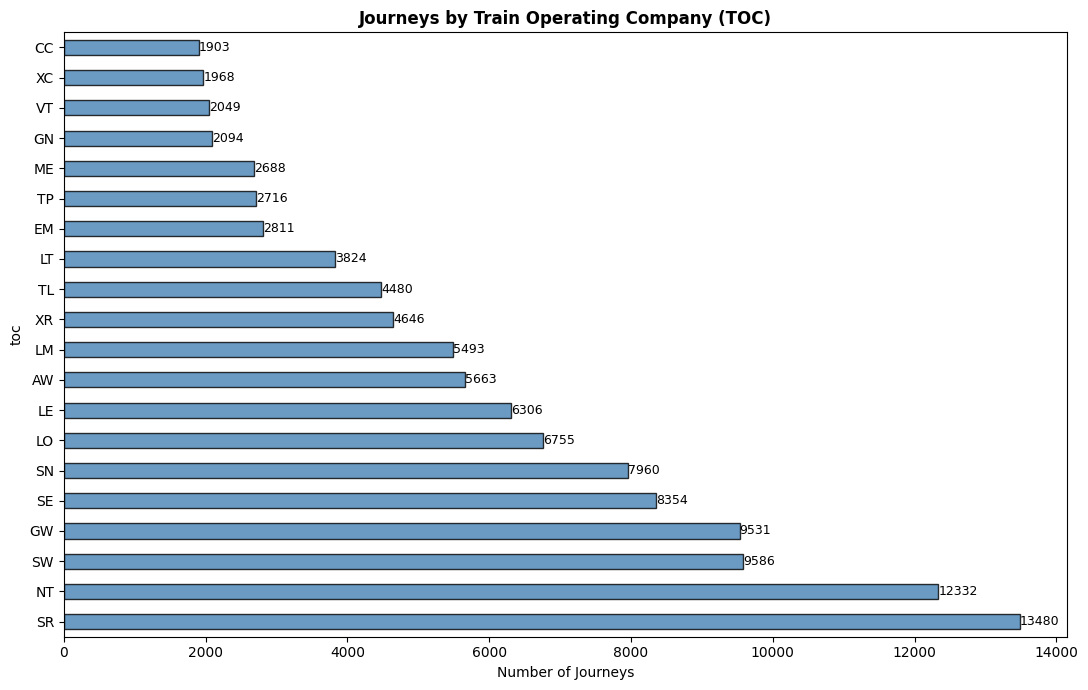

In [12]:
if "toc" in timetable_df.columns:
    journey_toc = timetable_df.drop_duplicates(subset=["rid"])["toc"].value_counts().head(20)
    plt.figure(figsize=(11, 7))
    journey_toc.plot(kind="barh", color="steelblue", edgecolor="black", alpha=0.8)
    plt.xlabel("Number of Journeys")
    plt.title("Journeys by Train Operating Company (TOC)", fontweight="bold")
    for i, v in enumerate(journey_toc.values):
        plt.text(v + 2, i, str(v), va="center", fontsize=9)
    plt.tight_layout()
    plt.savefig("figures/eda_04/toc_distribution.png", dpi=200, bbox_inches="tight")
    plt.show()

## 4. Stop Type Distribution

In [13]:
if "stop_type" in timetable_df.columns:
    stop_type_map = {
        "OR": "Origin", "OPOR": "Origin (optional)", 
        "IP": "Intermediate", "OPIP": "Intermediate (optional)",
        "PP": "Pass", "DT": "Destination", "OPDT": "Destination (optional)"
    }
    st_counts = timetable_df["stop_type"].value_counts()
    print("Stop type distribution:")
    for k, v in st_counts.items():
        label = stop_type_map.get(k, k)
        print(f"  {k:6s} ({label:30s}): {v:,} ({v/len(timetable_df)*100:.1f}%)")

Stop type distribution:
  IP     (Intermediate                  ): 865,609 (45.6%)
  PP     (Pass                          ): 760,174 (40.0%)
  DT     (Destination                   ): 95,214 (5.0%)
  OR     (Origin                        ): 95,196 (5.0%)
  OPIP   (Intermediate (optional)       ): 29,324 (1.5%)
  OPDT   (Destination (optional)        ): 26,555 (1.4%)
  OPOR   (Origin (optional)             ): 26,554 (1.4%)
  cancelReason (cancelReason                  ): 93 (0.0%)


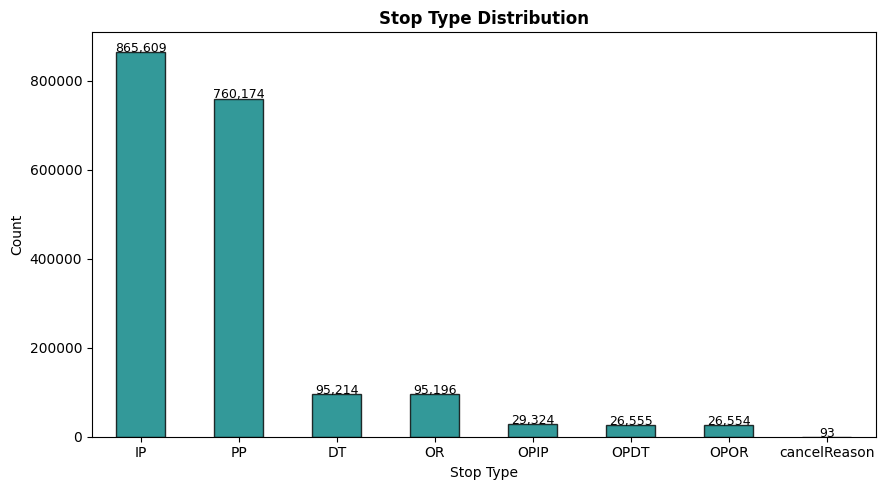

In [14]:
if "stop_type" in timetable_df.columns:
    st_counts = timetable_df["stop_type"].value_counts()
    plt.figure(figsize=(9, 5))
    st_counts.plot(kind="bar", color="teal", edgecolor="black", alpha=0.8)
    plt.xlabel("Stop Type")
    plt.ylabel("Count")
    plt.title("Stop Type Distribution", fontweight="bold")
    plt.tick_params(axis="x", rotation=0)
    for i, v in enumerate(st_counts.values):
        plt.text(i, v + 50, f"{v:,}", ha="center", fontsize=9)
    plt.tight_layout()
    plt.savefig("figures/eda_04/stop_type.png", dpi=200, bbox_inches="tight")
    plt.show()

## 5. Service Date Coverage

In [15]:
if "ssd" in timetable_df.columns:
    date_counts = timetable_df["ssd"].value_counts().sort_index()
    print("Stop rows by service date:")
    print(date_counts.to_string())
    print()
    journey_dates = timetable_df.drop_duplicates(subset=["rid"])["ssd"].value_counts().sort_index()
    print("Unique journeys by service date:")
    print(journey_dates.to_string())

Stop rows by service date:
ssd
2026-04-09      6030
2026-04-10    542722
2026-04-11    492747
2026-04-12    315042
2026-04-13    536278
2026-04-14      5900

Unique journeys by service date:
ssd
2026-04-09      527
2026-04-10    32930
2026-04-11    31477
2026-04-12    21982
2026-04-13    33323
2026-04-14      882


## 6. Planned Time Field Coverage

In [16]:
time_cols = [c for c in ["wta","wtd","wtp","pta","ptd"] if c in timetable_df.columns]

coverage = pd.DataFrame({
    "non_null": [timetable_df[c].notna().sum() for c in time_cols],
    "pct_present": [timetable_df[c].notna().mean()*100 for c in time_cols]
}, index=time_cols).round(2)
print(coverage.to_string())

     non_null  pct_present
wta   1016702        53.55
wtd   1016683        53.55
wtp    760174        40.04
pta    959065        50.51
ptd    957920        50.45


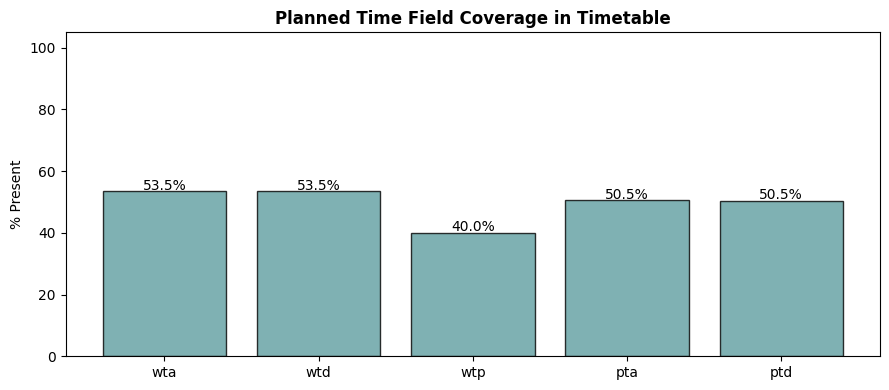

In [17]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(coverage.index, coverage["pct_present"], color="cadetblue",
       edgecolor="black", alpha=0.8)
ax.set_ylabel("% Present")
ax.set_title("Planned Time Field Coverage in Timetable", fontweight="bold")
ax.set_ylim(0, 105)
for i, v in enumerate(coverage["pct_present"]):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=10)
plt.tight_layout()
plt.savefig("figures/eda_04/time_field_coverage.png", dpi=200, bbox_inches="tight")
plt.show()

## 7. Service Frequency by Hour

In [18]:
# Use wtd (working time departure) as the primary scheduled time
time_col = "wtd" if "wtd" in timetable_df.columns else "wta"

def parse_hhmm(s):
    try:
        parts = str(s).strip().split(":")
        if len(parts) >= 2:
            return int(parts[0])
    except:
        pass
    return None

timetable_df["sched_hour"] = timetable_df[time_col].apply(parse_hhmm)
hour_counts = timetable_df["sched_hour"].dropna().astype(int).value_counts().sort_index()
print("Scheduled stop rows by hour:")
print(hour_counts.to_string())

Scheduled stop rows by hour:
sched_hour
0     16035
1      4495
2      1123
3       817
4      3327
5     17458
6     42763
7     53086
8     56295
9     57042
10    56043
11    55954
12    55702
13    55756
14    55901
15    56913
16    58757
17    60771
18    60359
19    57250
20    53575
21    50738
22    47183
23    39340


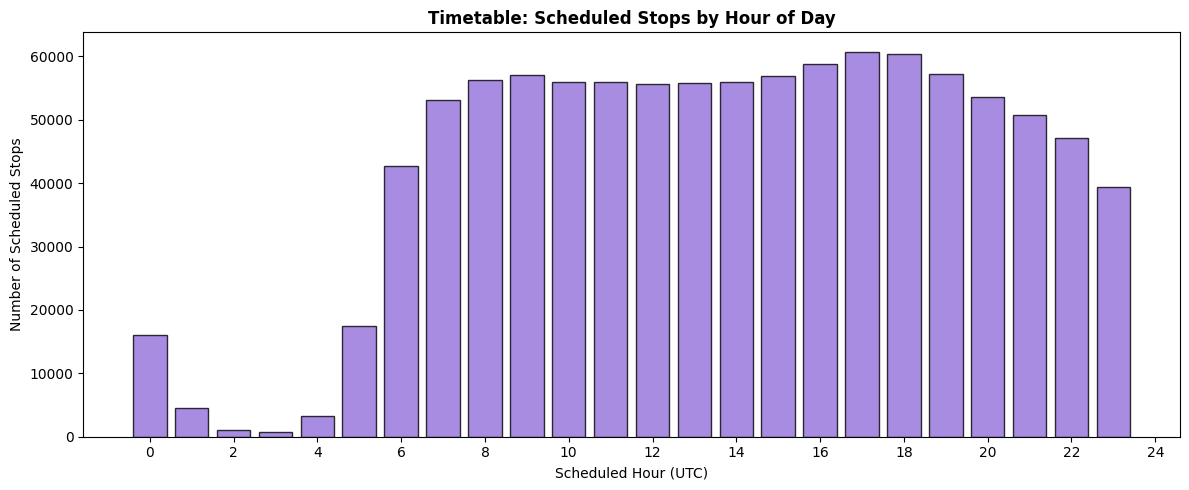

In [19]:
plt.figure(figsize=(12, 5))
plt.bar(hour_counts.index, hour_counts.values, color="mediumpurple",
        edgecolor="black", alpha=0.8)
plt.xlabel("Scheduled Hour (UTC)")
plt.ylabel("Number of Scheduled Stops")
plt.title("Timetable: Scheduled Stops by Hour of Day", fontweight="bold")
plt.xticks(range(0, 25, 2))
plt.tight_layout()
plt.savefig("figures/eda_04/service_frequency_by_hour.png", dpi=200, bbox_inches="tight")
plt.show()

## 8. Journey-Level Statistics

In [20]:
if "rid" in timetable_df.columns:
    stops_per_journey = timetable_df.groupby("rid").size()
    print("Stops per journey statistics:")
    print(stops_per_journey.describe().round(1))
    print()
    print(f"Journeys with only 1 stop:   {(stops_per_journey == 1).sum():,}")
    print(f"Journeys with 2-5 stops:     {((stops_per_journey >= 2) & (stops_per_journey <= 5)).sum():,}")
    print(f"Journeys with 6-15 stops:    {((stops_per_journey >= 6) & (stops_per_journey <= 15)).sum():,}")
    print(f"Journeys with > 15 stops:    {(stops_per_journey > 15).sum():,}")

Stops per journey statistics:
count    121121.0
mean         15.7
std          13.1
min           2.0
25%           4.0
50%          14.0
75%          22.0
max         150.0
dtype: float64

Journeys with only 1 stop:   0
Journeys with 2-5 stops:     33,737
Journeys with 6-15 stops:    32,355
Journeys with > 15 stops:    55,029


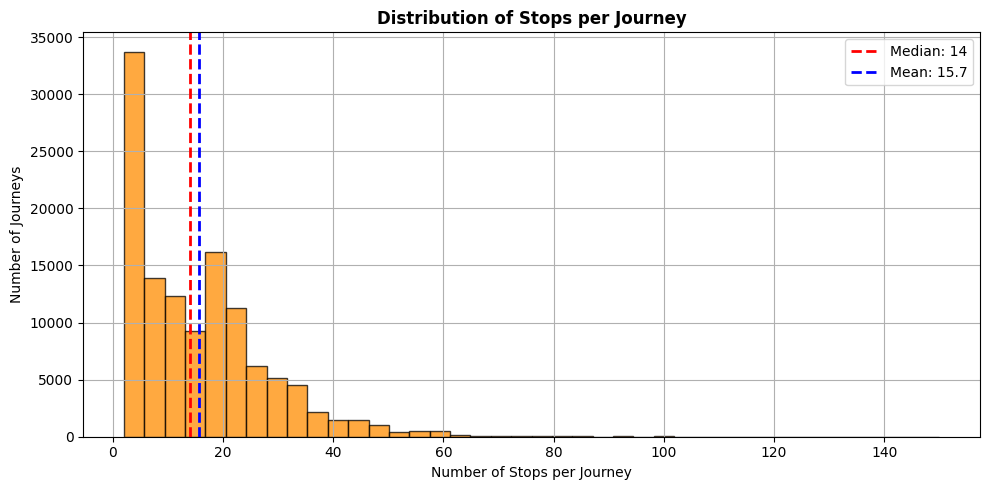

In [21]:
if "rid" in timetable_df.columns:
    stops_per_journey = timetable_df.groupby("rid").size()
    plt.figure(figsize=(10, 5))
    stops_per_journey.hist(bins=40, edgecolor="black", alpha=0.75, color="darkorange")
    plt.axvline(stops_per_journey.median(), color="red", linestyle="--", lw=2,
                label=f"Median: {stops_per_journey.median():.0f}")
    plt.axvline(stops_per_journey.mean(), color="blue", linestyle="--", lw=2,
                label=f"Mean: {stops_per_journey.mean():.1f}")
    plt.xlabel("Number of Stops per Journey")
    plt.ylabel("Number of Journeys")
    plt.title("Distribution of Stops per Journey", fontweight="bold")
    plt.legend()
    plt.tight_layout()
    plt.savefig("figures/eda_04/stops_per_journey.png", dpi=200, bbox_inches="tight")
    plt.show()

## 9. TIPLOC Match Rate

In [22]:
if "tpl" in timetable_df.columns and "tiploc" in stations_reference_df.columns:
    timetable_tpls = set(timetable_df["tpl"].dropna().str.strip().str.upper())
    stations_reference_tpls    = set(stations_reference_df["tiploc"].dropna().str.strip().str.upper())
    matched        = timetable_tpls & stations_reference_tpls
    unmatched      = timetable_tpls - stations_reference_tpls

    print(f"Unique TPLs in timetable:     {len(timetable_tpls):,}")
    print(f"tiploc codes in stations:     {len(stations_reference_tpls):,}")
    print(f"Matched:                      {len(matched):,} ({len(matched)/len(timetable_tpls)*100:.1f}%)")
    print(f"Unmatched (timetable only):   {len(unmatched):,}")

    # Row-level match rate
    row_match = timetable_df["tpl"].str.strip().str.upper().isin(stations_reference_tpls)
    print(f"\nStop rows with matched TIPLOC: {row_match.sum():,} ({row_match.mean()*100:.1f}%)")
    print(f"Stop rows without match:        {(~row_match).sum():,} ({(~row_match).mean()*100:.1f}%)")

Unique TPLs in timetable:     5,003
tiploc codes in stations:     2,594
Matched:                      2,583 (51.6%)
Unmatched (timetable only):   2,420

Stop rows with matched TIPLOC: 1,166,537 (61.4%)
Stop rows without match:        732,182 (38.6%)


## 10. Save Cleaned Output

In [23]:
clean = timetable_df.copy()
print(f"Final timetable dataset: {len(clean):,} rows")
clean.to_parquet("./data/processed/darwin_timetable_clean.parquet", index=False)
print("Saved to data/processed/darwin_timetable_clean.parquet")

Final timetable dataset: 1,898,719 rows
Saved to data/processed/darwin_timetable_clean.parquet


In [24]:
clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898719 entries, 0 to 1898718
Data columns (total 15 columns):
 #   Column      Dtype  
---  ------      -----  
 0   rid         object 
 1   uid         object 
 2   trainId     object 
 3   ssd         object 
 4   toc         object 
 5   stop_type   object 
 6   tpl         object 
 7   platform    object 
 8   act         object 
 9   pta         object 
 10  ptd         object 
 11  wta         object 
 12  wtd         object 
 13  wtp         object 
 14  sched_hour  float64
dtypes: float64(1), object(14)
memory usage: 217.3+ MB
